
n_min = 2
n = 2: Naive = 1.0e-7, Strass = 2.0e-7, Winograd = 3.0e-7, Delta = 1.0e-7
  Strass = Naive: true, Winograd = Naive: true
n = 4: Naive = 2.0e-7, Strass = 3.5e-6, Winograd = 3.0e-7, Delta = 3.2999999999999997e-6
  Strass = Naive: true, Winograd = Naive: true
n = 8: Naive = 6.0e-7, Strass = 1.61e-5, Winograd = 9.0e-7, Delta = 1.5499999999999997e-5
  Strass = Naive: true, Winograd = Naive: true
n = 16: Naive = 4.5e-6, Strass = 0.0001057, Winograd = 3.7e-6, Delta = 0.0001012
  Strass = Naive: true, Winograd = Naive: true
n = 32: Naive = 4.86e-5, Strass = 0.0011179, Winograd = 3.28e-5, Delta = 0.0010693
  Strass = Naive: true, Winograd = Naive: true
n = 64: Naive = 0.0004282, Strass = 0.0126865, Winograd = 0.0002149, Delta = 0.0122583
  Strass = Naive: true, Winograd = Naive: true
n = 128: Naive = 0.0039392, Strass = 0.0608191, Winograd = 0.0021011, Delta = 0.0568799
  Strass = Naive: true, Winograd = Naive: true
n = 256: Naive = 0.0325221, Strass = 0.5682007, Winograd = 0.0168652

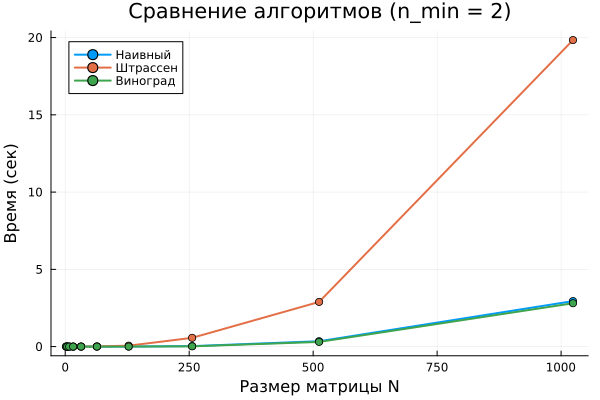

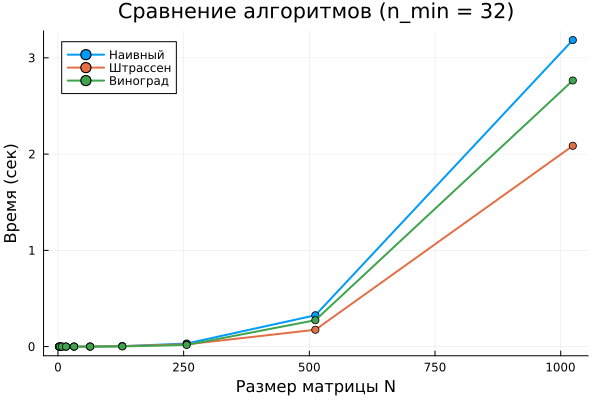

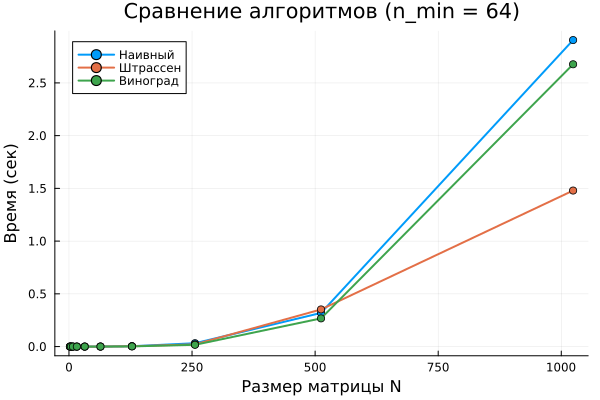

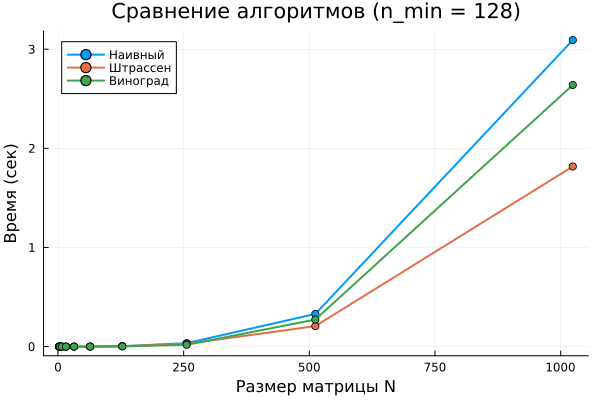

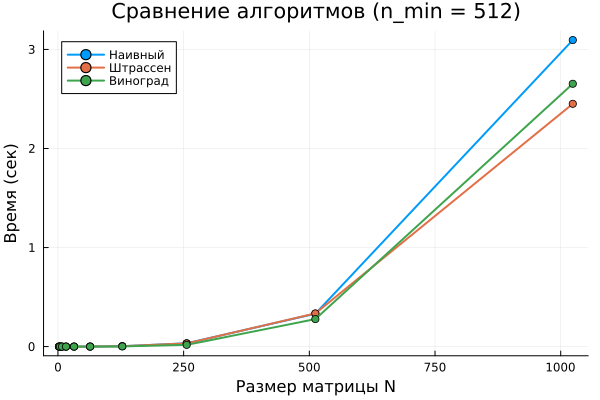

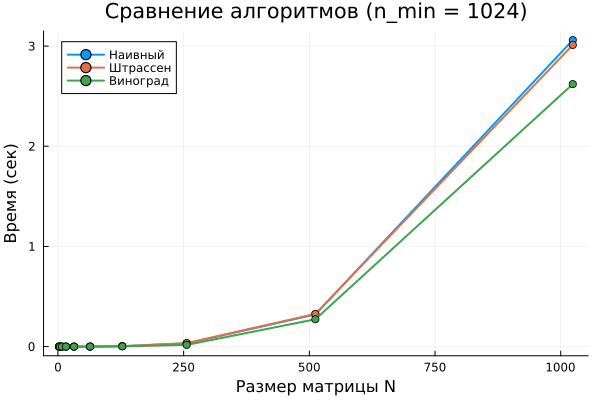

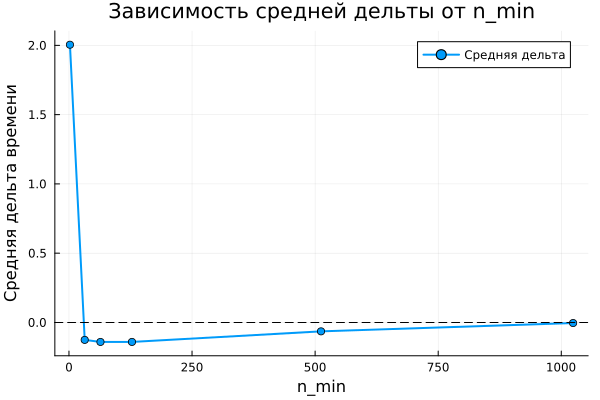

In [8]:
using Plots
using Statistics

function generate_matrix(n::Int, m::Int)
    return rand(Float64, n, m)
end

function naive_multiply(A::Matrix{Float64}, B::Matrix{Float64})
    n = size(A, 1)
    C = zeros(Float64, n, n)
    for i in 1:n
        for j in 1:n
            for k in 1:n
                C[i, j] += A[i, k] * B[k, j]
            end
        end
    end
    return C
end

function strass(A::Matrix{Float64}, B::Matrix{Float64}, n_min::Int = 64)
    A = copy(A)
    B = copy(B)
    n = size(A, 1)
    if n <= n_min
        return naive_multiply(A, B)
    end

    m = div(n, 2)
    A11 = A[1:m, 1:m]
    A12 = A[1:m, m+1:end]
    A21 = A[m+1:end, 1:m]
    A22 = A[m+1:end, m+1:end]

    B11 = B[1:m, 1:m]
    B12 = B[1:m, m+1:end]
    B21 = B[m+1:end, 1:m]
    B22 = B[m+1:end, m+1:end]

    P1 = strass(A11 + A22, B11 + B22, n_min)
    P2 = strass(A21 + A22, B11, n_min)
    P3 = strass(A11, B12 - B22, n_min)
    P4 = strass(A22, B21 - B11, n_min)
    P5 = strass(A11 + A12, B22, n_min)
    P6 = strass(A21 - A11, B11 + B12, n_min)
    P7 = strass(A12 - A22, B21 + B22, n_min)

    C11 = P1 + P4 - P5 + P7
    C12 = P3 + P5
    C21 = P2 + P4
    C22 = P1 + P3 - P2 + P6

    C = zeros(Float64, n, n)
    C[1:m, 1:m] = C11
    C[1:m, m+1:end] = C12
    C[m+1:end, 1:m] = C21
    C[m+1:end, m+1:end] = C22
    return C
end

function winograd(A::Matrix{Float64}, B::Matrix{Float64})
    n = size(A, 1)
    C = zeros(Float64, n, n)
    
    m = div(n, 2)
    
    row_sum = zeros(Float64, n)
    for i in 1:n
        row_sum[i] = sum(A[i, 2*k-1] * A[i, 2*k] for k in 1:m)
    end

    col_sum = zeros(Float64, n)
    for j in 1:n
        col_sum[j] = sum(B[2*k-1, j] * B[2*k, j] for k in 1:m)
    end
    
    for i in 1:n
        for j in 1:n
            C[i, j] = -row_sum[i] - col_sum[j]
            for k in 1:m
                C[i, j] += (A[i, 2*k-1] + B[2*k, j]) * (A[i, 2*k] + B[2*k-1, j])
            end
        end
    end
    return C
end

function main()
    n_min_values = [2, 32, 64, 128, 512, 1024]
    sizes = [2^i for i in 1:10]
    average_deltas = Float64[]
    
    for n_min in n_min_values
        times_strass = Float64[]
        times_naive = Float64[]
        times_winograd = Float64[]
        deltas = Float64[]
        
        println("\nn_min = $n_min")
        
        for n in sizes
            A = generate_matrix(n, n)
            B = generate_matrix(n, n)
            
            C_naive = naive_multiply(A, B)
            C_strass = strass(A, B, n_min)
            C_winograd = winograd(A, B)
            is_strass_equal = isapprox(C_naive, C_strass)
            is_winograd_equal = isapprox(C_naive, C_winograd)
            
            time_strass = @elapsed strass(A, B, n_min)
            time_naive = @elapsed naive_multiply(A, B)
            time_winograd = @elapsed winograd(A, B)
            
            delta = time_strass - time_naive
            
            push!(times_strass, time_strass)
            push!(times_naive, time_naive)
            push!(times_winograd, time_winograd)
            push!(deltas, delta)
            
            println("n = $n: Naive = $time_naive, Strass = $time_strass, Winograd = $time_winograd, Delta = $delta")
            println("  Strass = Naive: $is_strass_equal, Winograd = Naive: $is_winograd_equal")
        end
        
        p = plot(sizes, [times_naive, times_strass, times_winograd], 
                 label=["Наивный" "Штрассен" "Виноград"], 
                 xlabel="Размер матрицы N", 
                 ylabel="Время (сек)",
                 title="Сравнение алгоритмов (n_min = $n_min)",
                 linewidth=2,
                 marker=:circle)
        display(p)
        
        avg_delta = mean(deltas)
        push!(average_deltas, avg_delta)
        println("Средняя дельта для n_min = $n_min: $avg_delta")
    end
    
    p_final = plot(n_min_values, average_deltas,
                   label="Средняя дельта",
                   xlabel="n_min",
                   ylabel="Средняя дельта времени",
                   title="Зависимость средней дельты от n_min",
                   linewidth=2,
                   marker=:circle,
                   linestyle=:solid,
                   ylims=(minimum(average_deltas) - 0.1, maximum(average_deltas) + 0.1))
    hline!(p_final, [0], linestyle=:dash, color=:black, label="", linewidth=1)
    display(p_final)
    
    println("\nИтоговые результаты")
    for (i, n_min) in enumerate(n_min_values)
        println("n_min = $n_min: средняя дельта = $(average_deltas[i])")
    end
    
    best_index = argmin(average_deltas)
    best_n_min = n_min_values[best_index]
    best_delta = average_deltas[best_index]
    println("Лучший n_min = $best_n_min (средняя дельта = $best_delta)")
end

main()